Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATASET SHAPE
(7043, 21)
FIRST FIVE ROWS
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL          

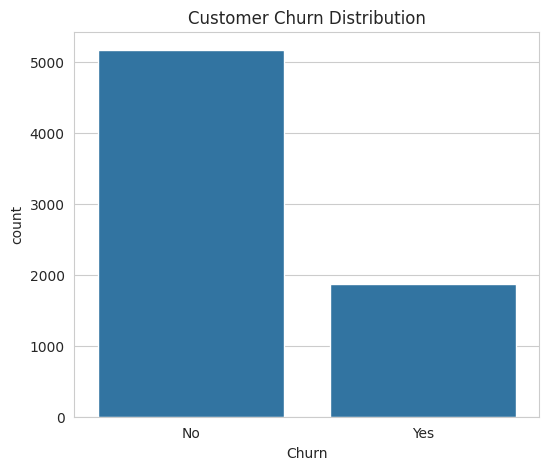

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


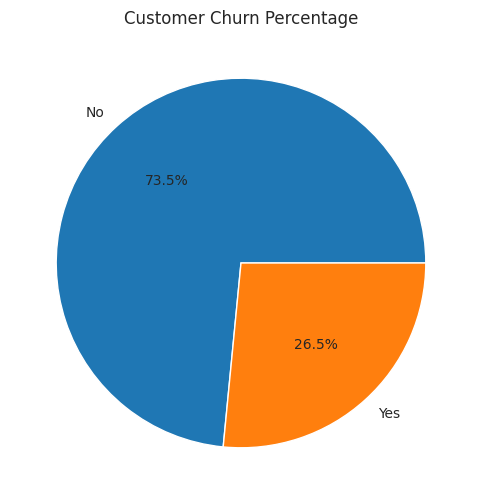

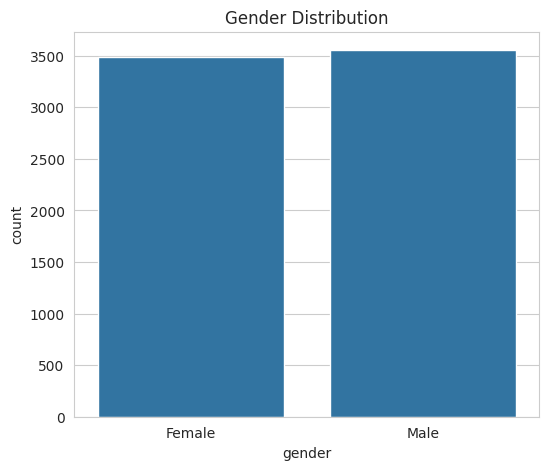

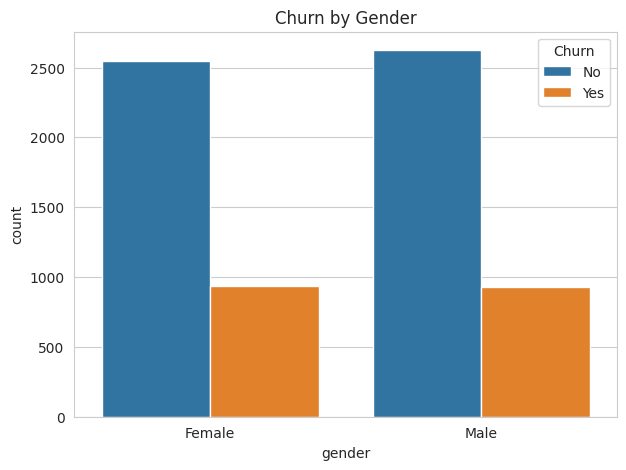

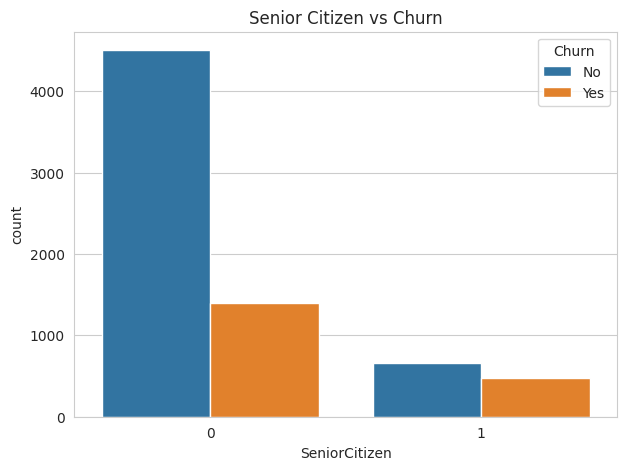

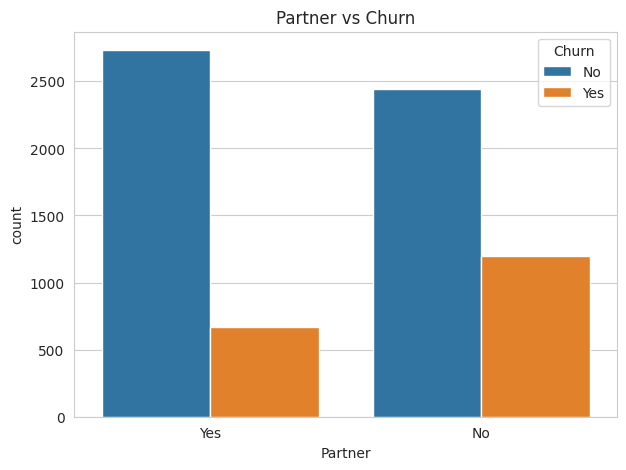

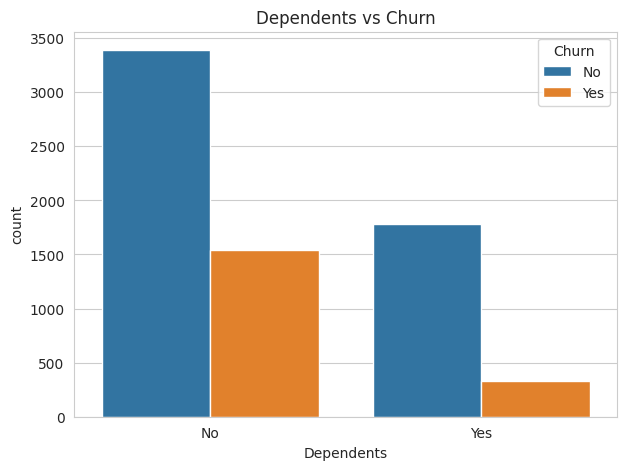

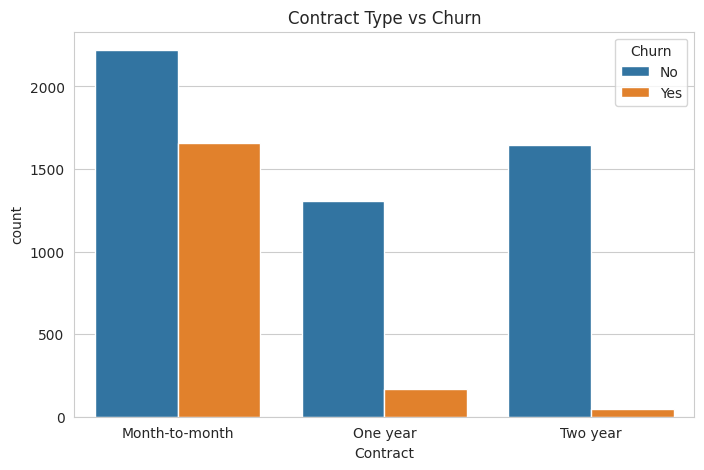

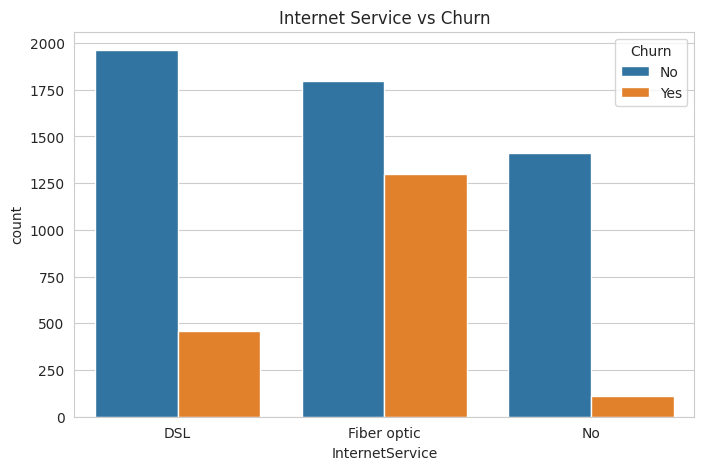

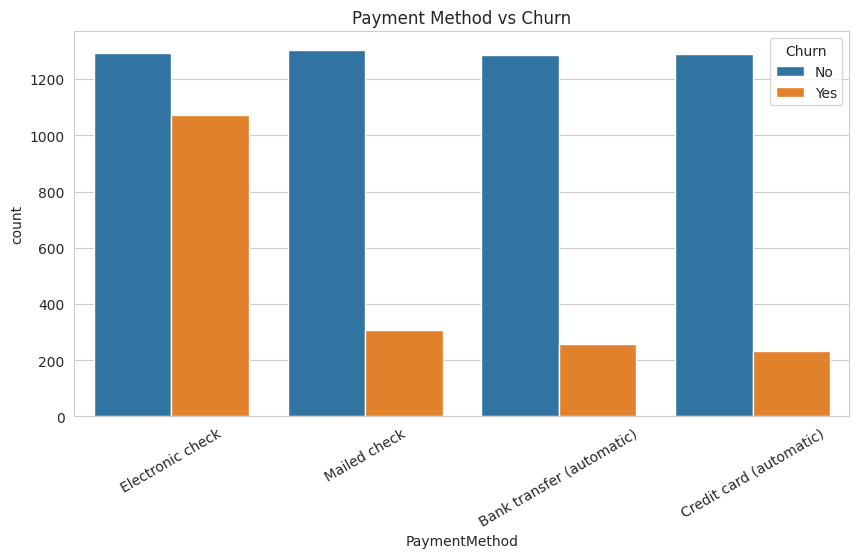

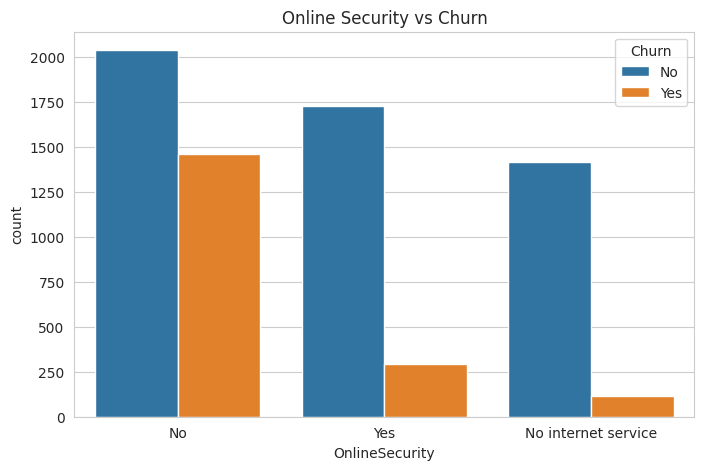

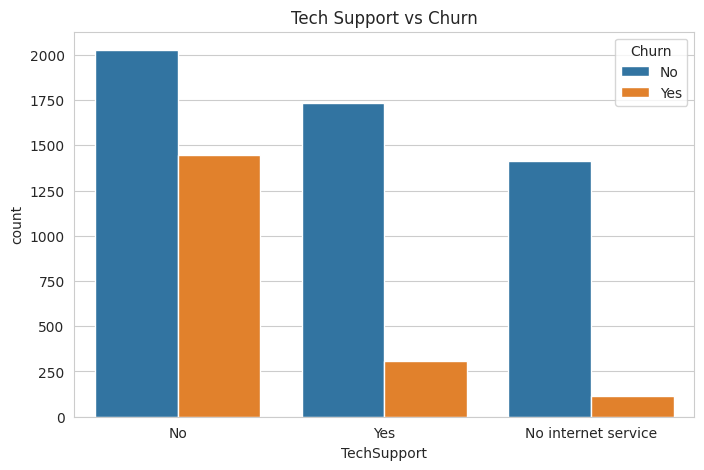

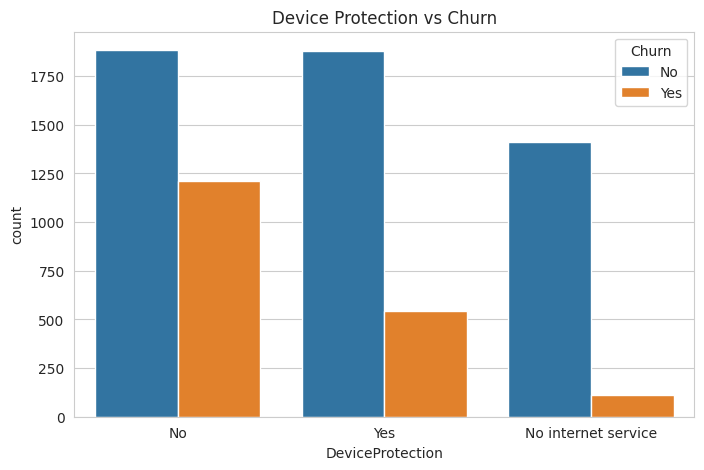

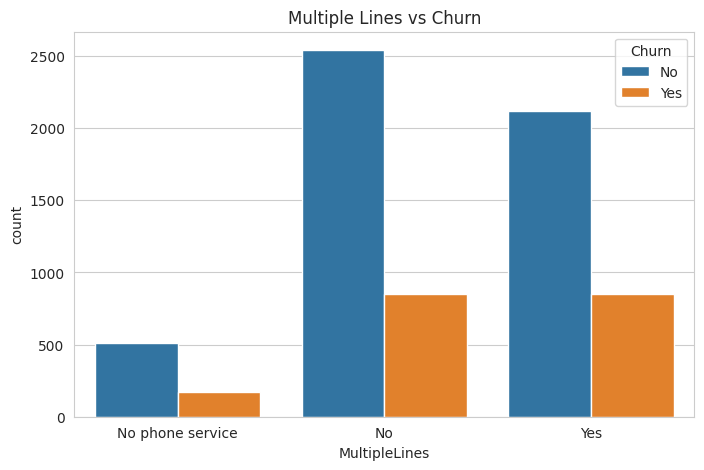

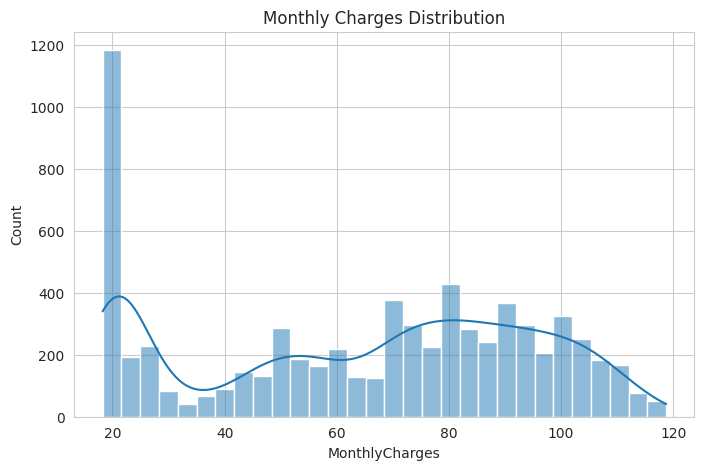

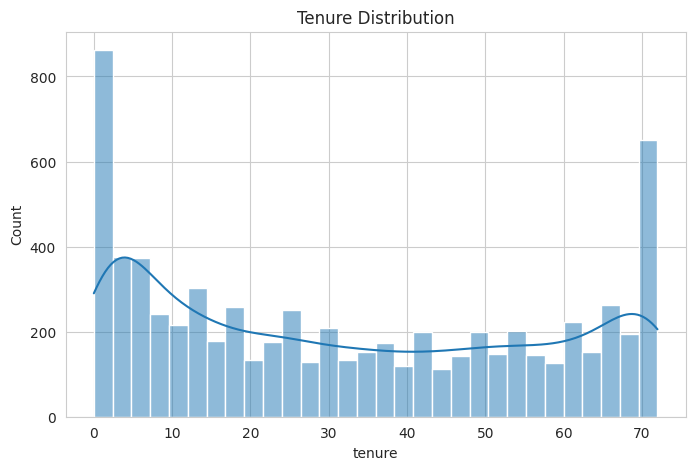

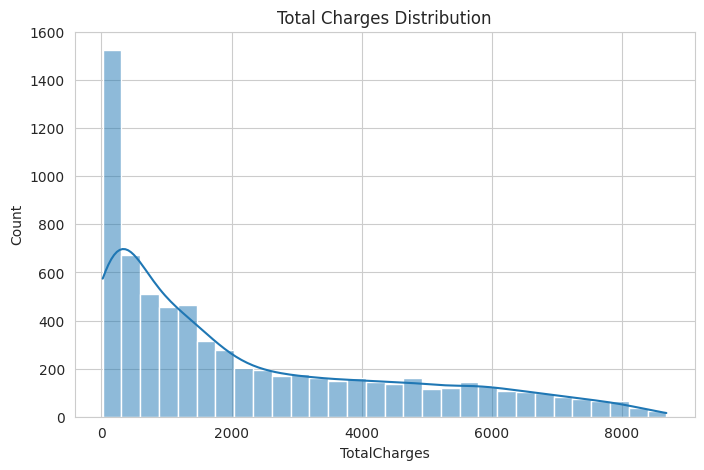

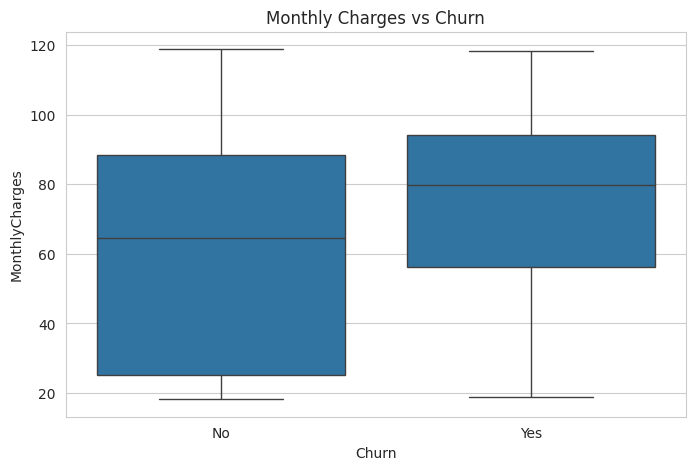

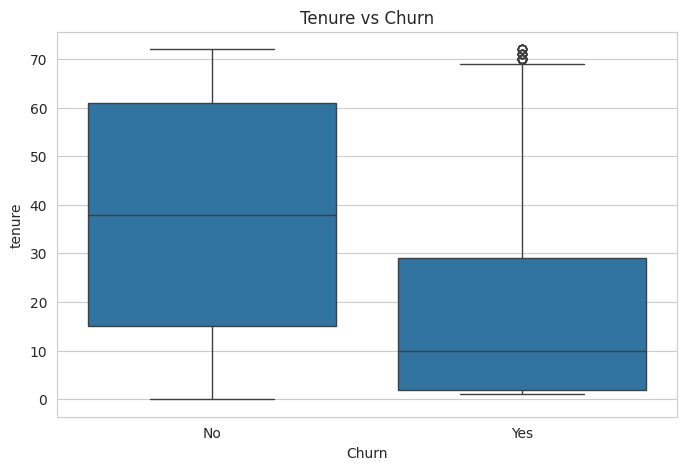

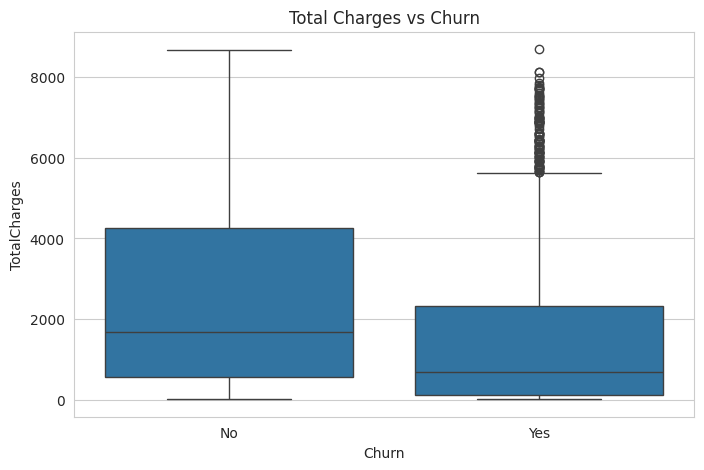

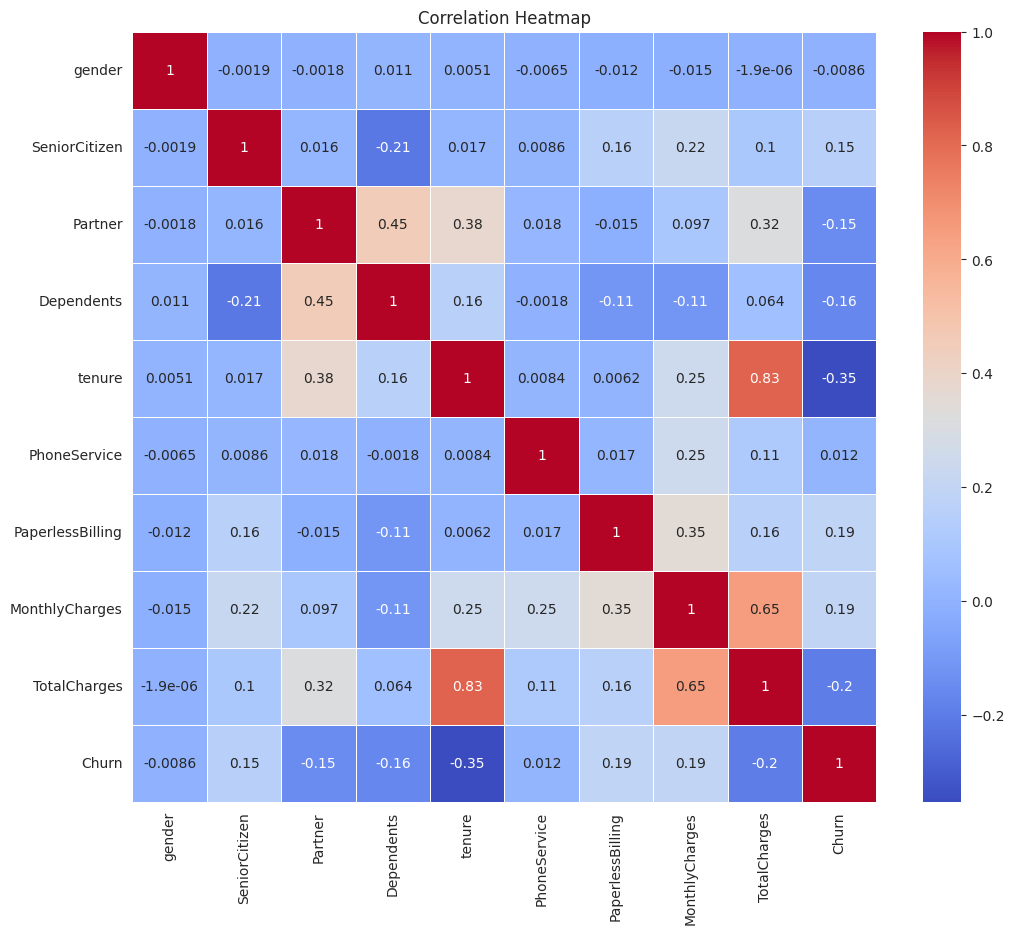


Contract vs Churn (%)
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


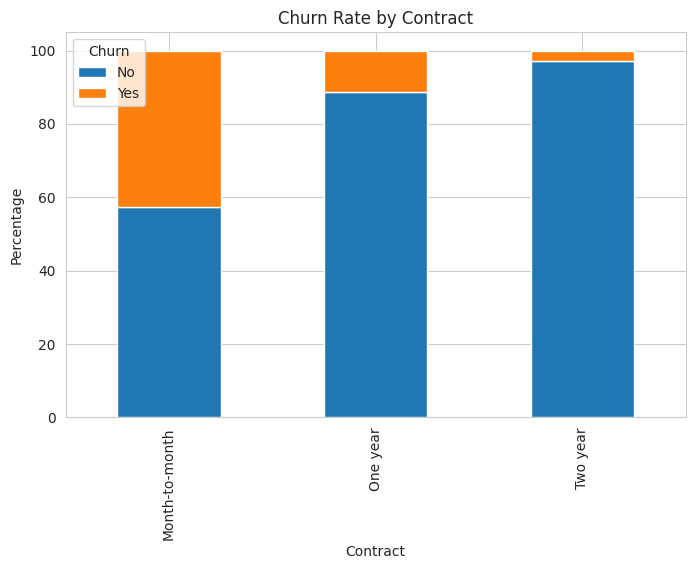


Internet Service vs Churn (%)
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


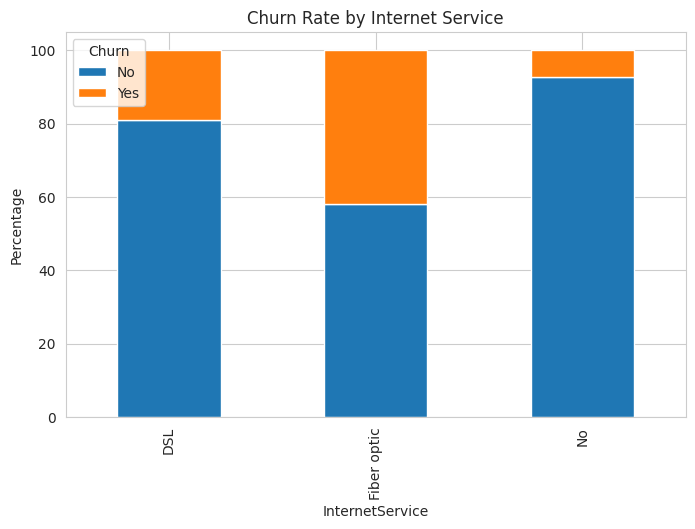


Payment Method vs Churn (%)
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11


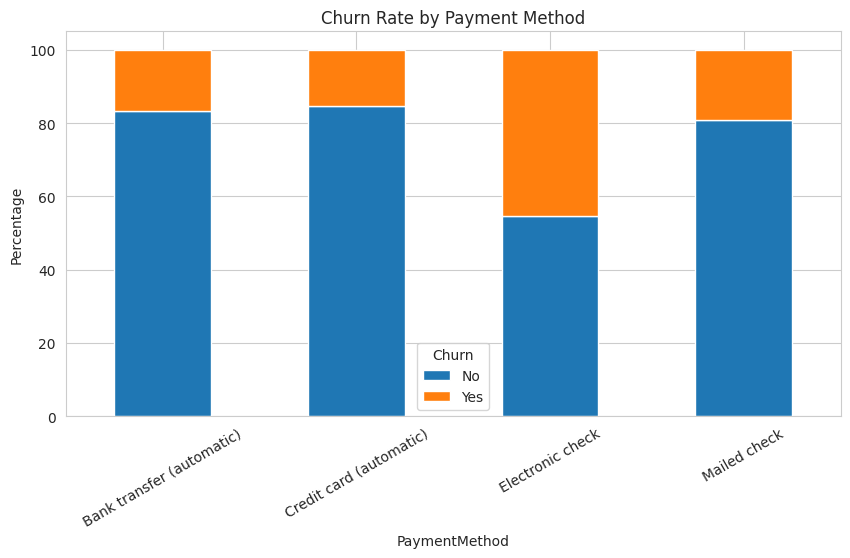

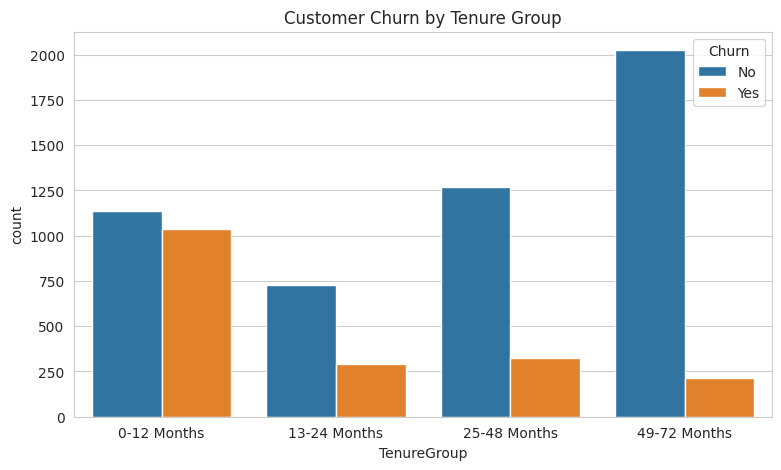

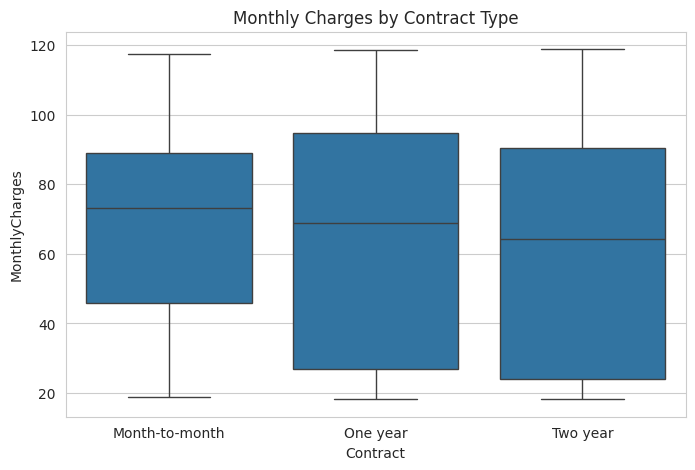

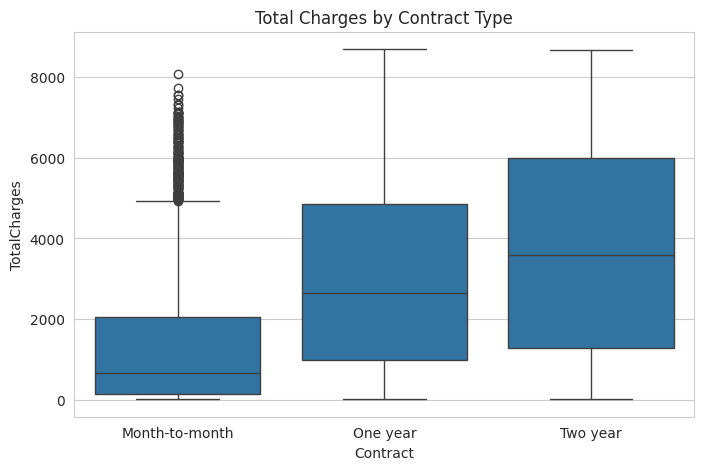


Customer Profile
       MonthlyCharges  TotalCharges  tenure
Churn                                      
No              61.27       2552.88   37.57
Yes             74.44       1531.80   17.98

Average Monthly Charges
Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

Average Total Charges
Churn
No     2552.882494
Yes    1531.796094
Name: TotalCharges, dtype: float64

Average Tenure
Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

gender vs Churn (%)
Churn     No   Yes
gender            
Female  73.1  26.9
Male    73.8  26.2

SeniorCitizen vs Churn (%)
Churn            No   Yes
SeniorCitizen            
0              76.4  23.6
1              58.3  41.7

Partner vs Churn (%)
Churn      No   Yes
Partner            
No       67.0  33.0
Yes      80.3  19.7

Dependents vs Churn (%)
Churn         No   Yes
Dependents            
No          68.7  31.3
Yes         84.5  15.5

PhoneService vs Churn (%)
Churn           No   Yes
PhoneService     

In [2]:
# ==========================================================
# BUSINESS ANALYTICS CASE STUDY
# TELCO CUSTOMER CHURN ANALYSIS
# PART 1
# ==========================================================

# =============================
# IMPORT LIBRARIES
# =============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# =============================
# MOUNT GOOGLE DRIVE
# =============================

from google.colab import drive
drive.mount('/content/drive')

# =============================
# LOAD DATASET
# =============================

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Business Analytics Case Study/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# =============================
# CREATE FOLDER TO SAVE CHARTS
# =============================

save_path="/content/drive/MyDrive/Colab Notebooks/Business Analytics Case Study/Charts"

os.makedirs(save_path,exist_ok=True)

# =============================
# DATASET OVERVIEW
# =============================

print("="*60)
print("DATASET SHAPE")
print(df.shape)

print("="*60)
print("FIRST FIVE ROWS")
print(df.head())

print("="*60)
print("COLUMN NAMES")
print(df.columns)

print("="*60)
print("DATA TYPES")
print(df.info())

# =============================
# MISSING VALUES
# =============================

print("="*60)
print(df.isnull().sum())

print("="*60)
print("Blank Values")
print((df==" ").sum())

# Convert TotalCharges to numeric
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

# Fill missing values
df["TotalCharges"].fillna(df["TotalCharges"].median(),inplace=True)

print("="*60)
print("Missing values after cleaning")
print(df.isnull().sum())

# =============================
# DUPLICATES
# =============================

print("="*60)
print("Duplicate Rows")
print(df.duplicated().sum())

# =============================
# SUMMARY STATISTICS
# =============================

print(df.describe())

print(df.describe(include="object"))

# ==========================================================
# CHURN DISTRIBUTION
# ==========================================================

plt.figure(figsize=(6,5))

sns.countplot(data=df,x="Churn")

plt.title("Customer Churn Distribution")

plt.savefig(f"{save_path}/01_Churn_Distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

print(df["Churn"].value_counts())

print(df["Churn"].value_counts(normalize=True)*100)

# ==========================================================
# PIE CHART
# ==========================================================

plt.figure(figsize=(6,6))

df["Churn"].value_counts().plot(
kind="pie",
autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Customer Churn Percentage")

plt.savefig(f"{save_path}/02_Churn_Pie.png",
dpi=300,
bbox_inches="tight")

plt.show()

# ==========================================================
# GENDER
# ==========================================================

plt.figure(figsize=(6,5))

sns.countplot(data=df,x="gender")

plt.title("Gender Distribution")

plt.savefig(f"{save_path}/03_Gender.png",
dpi=300,
bbox_inches="tight")

plt.show()

# ==========================================================
# GENDER VS CHURN
# ==========================================================

plt.figure(figsize=(7,5))

sns.countplot(data=df,
x="gender",
hue="Churn")

plt.title("Churn by Gender")

plt.savefig(f"{save_path}/04_Gender_Churn.png",
dpi=300,
bbox_inches="tight")

plt.show()

# ==========================================================
# SENIOR CITIZEN
# ==========================================================

plt.figure(figsize=(7,5))

sns.countplot(data=df,
x="SeniorCitizen",
hue="Churn")

plt.title("Senior Citizen vs Churn")

plt.savefig(f"{save_path}/05_SeniorCitizen.png",
dpi=300,
bbox_inches="tight")

plt.show()

# ==========================================================
# PARTNER
# ==========================================================

plt.figure(figsize=(7,5))

sns.countplot(data=df,
x="Partner",
hue="Churn")

plt.title("Partner vs Churn")

plt.savefig(f"{save_path}/06_Partner.png",
dpi=300,
bbox_inches="tight")

plt.show()

# ==========================================================
# DEPENDENTS
# ==========================================================

plt.figure(figsize=(7,5))

sns.countplot(data=df,
x="Dependents",
hue="Churn")

plt.title("Dependents vs Churn")

plt.savefig(f"{save_path}/07_Dependents.png",
dpi=300,
bbox_inches="tight")

plt.show()

# ==========================================================
# CONTRACT
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(data=df,
x="Contract",
hue="Churn")

plt.title("Contract Type vs Churn")

plt.savefig(f"{save_path}/08_Contract.png",
dpi=300,
bbox_inches="tight")

plt.show()

# ==========================================================
# INTERNET SERVICE
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(data=df,
x="InternetService",
hue="Churn")

plt.title("Internet Service vs Churn")

plt.savefig(f"{save_path}/09_Internet.png",
dpi=300,
bbox_inches="tight")

plt.show()

# ==========================================================
# PAYMENT METHOD
# ==========================================================

plt.figure(figsize=(10,5))

sns.countplot(data=df,
x="PaymentMethod",
hue="Churn")

plt.xticks(rotation=30)

plt.title("Payment Method vs Churn")

plt.savefig(f"{save_path}/10_Payment.png",
dpi=300,
bbox_inches="tight")

plt.show()

# ==========================================================
# ONLINE SECURITY
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(data=df,
x="OnlineSecurity",
hue="Churn")

plt.title("Online Security vs Churn")

plt.savefig(f"{save_path}/11_OnlineSecurity.png",
dpi=300,
bbox_inches="tight")

plt.show()

# ==========================================================
# TECH SUPPORT
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(data=df,
x="TechSupport",
hue="Churn")

plt.title("Tech Support vs Churn")

plt.savefig(f"{save_path}/12_TechSupport.png",
dpi=300,
bbox_inches="tight")

plt.show()

# ==========================================================
# DEVICE PROTECTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(data=df,
x="DeviceProtection",
hue="Churn")

plt.title("Device Protection vs Churn")

plt.savefig(f"{save_path}/13_DeviceProtection.png",
dpi=300,
bbox_inches="tight")

plt.show()

# ==========================================================
# MULTIPLE LINES
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(data=df,
x="MultipleLines",
hue="Churn")

plt.title("Multiple Lines vs Churn")

plt.savefig(f"{save_path}/14_MultipleLines.png",
dpi=300,
bbox_inches="tight")

plt.show()

# ==========================================================
# MONTHLY CHARGES HISTOGRAM
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyCharges"],
bins=30,
kde=True)

plt.title("Monthly Charges Distribution")

plt.savefig(f"{save_path}/15_MonthlyCharges.png",
dpi=300,
bbox_inches="tight")

plt.show()

# ==========================================================
# TENURE HISTOGRAM
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(df["tenure"],
bins=30,
kde=True)

plt.title("Tenure Distribution")

plt.savefig(f"{save_path}/16_Tenure.png",
dpi=300,
bbox_inches="tight")

plt.show()

# ==========================================================
# TOTAL CHARGES HISTOGRAM
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(df["TotalCharges"],
bins=30,
kde=True)

plt.title("Total Charges Distribution")

plt.savefig(f"{save_path}/17_TotalCharges.png",
dpi=300,
bbox_inches="tight")

plt.show()

# ==========================================================
# MONTHLY CHARGES BOXPLOT
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(data=df,
x="Churn",
y="MonthlyCharges")

plt.title("Monthly Charges vs Churn")

plt.savefig(f"{save_path}/18_Box_MonthlyCharges.png",
dpi=300,
bbox_inches="tight")

plt.show()

# ==========================================================
# TENURE BOXPLOT
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(data=df,
x="Churn",
y="tenure")

plt.title("Tenure vs Churn")

plt.savefig(f"{save_path}/19_Box_Tenure.png",
dpi=300,
bbox_inches="tight")

plt.show()

# ==========================================================
# TOTAL CHARGES BOXPLOT
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(data=df,
x="Churn",
y="TotalCharges")

plt.title("Total Charges vs Churn")

plt.savefig(f"{save_path}/20_Box_TotalCharges.png",
dpi=300,
bbox_inches="tight")

plt.show()

# ==========================================================
# BUSINESS ANALYTICS CASE STUDY
# TELCO CUSTOMER CHURN ANALYSIS
# PART 2
# ==========================================================

# ==========================================================
# CORRELATION HEATMAP
# ==========================================================

df_corr = df.copy()

binary_map = {"Yes":1, "No":0}

# Convert binary Yes/No columns
for col in df_corr.columns:
    df_corr[col] = df_corr[col].replace(binary_map)

# Convert Gender
df_corr["gender"] = df_corr["gender"].replace({"Male":1,"Female":0})

# Convert Churn
df_corr["Churn"] = df_corr["Churn"].replace({"Yes":1,"No":0})

# Select only numeric columns
corr = df_corr.select_dtypes(include="number").corr()

plt.figure(figsize=(12,10))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            linewidths=.5)

plt.title("Correlation Heatmap")

plt.savefig(f"{save_path}/21_Correlation_Heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# ==========================================================
# CHURN RATE BY CONTRACT
# ==========================================================

contract = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print("\nContract vs Churn (%)")
print(contract.round(2))

contract.plot(kind="bar",
              stacked=True,
              figsize=(8,5))

plt.ylabel("Percentage")
plt.title("Churn Rate by Contract")

plt.savefig(f"{save_path}/22_Contract_Rate.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# ==========================================================
# INTERNET SERVICE
# ==========================================================

internet = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print("\nInternet Service vs Churn (%)")
print(internet.round(2))

internet.plot(kind="bar",
              stacked=True,
              figsize=(8,5))

plt.ylabel("Percentage")
plt.title("Churn Rate by Internet Service")

plt.savefig(f"{save_path}/23_Internet_Rate.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# ==========================================================
# PAYMENT METHOD
# ==========================================================

payment = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print("\nPayment Method vs Churn (%)")
print(payment.round(2))

payment.plot(kind="bar",
             stacked=True,
             figsize=(10,5))

plt.xticks(rotation=30)

plt.ylabel("Percentage")
plt.title("Churn Rate by Payment Method")

plt.savefig(f"{save_path}/24_Payment_Rate.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# ==========================================================
# TENURE GROUPS
# ==========================================================

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

plt.figure(figsize=(9,5))

sns.countplot(data=df,
              x="TenureGroup",
              hue="Churn")

plt.title("Customer Churn by Tenure Group")

plt.savefig(f"{save_path}/25_Tenure_Group.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# ==========================================================
# MONTHLY CHARGES BY CONTRACT
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x="Contract",
            y="MonthlyCharges")

plt.title("Monthly Charges by Contract Type")

plt.savefig(f"{save_path}/26_MonthlyCharges_Contract.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# ==========================================================
# TOTAL CHARGES BY CONTRACT
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x="Contract",
            y="TotalCharges")

plt.title("Total Charges by Contract Type")

plt.savefig(f"{save_path}/27_TotalCharges_Contract.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# ==========================================================
# CUSTOMER PROFILE
# ==========================================================

profile = df.groupby("Churn").agg({
    "MonthlyCharges":"mean",
    "TotalCharges":"mean",
    "tenure":"mean"
}).round(2)

print("\nCustomer Profile")
print(profile)

# ==========================================================
# AVERAGE VALUES
# ==========================================================

print("\nAverage Monthly Charges")
print(df.groupby("Churn")["MonthlyCharges"].mean())

print("\nAverage Total Charges")
print(df.groupby("Churn")["TotalCharges"].mean())

print("\nAverage Tenure")
print(df.groupby("Churn")["tenure"].mean())

# ==========================================================
# CHURN PERCENTAGE BY CATEGORY
# ==========================================================

categorical = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "InternetService",
    "Contract",
    "PaymentMethod",
    "OnlineSecurity",
    "TechSupport",
    "DeviceProtection",
    "MultipleLines"
]

for col in categorical:
    print("\n" + "="*60)
    print(f"{col} vs Churn (%)")
    print(pd.crosstab(df[col],
                      df["Churn"],
                      normalize="index").round(3)*100)

# ==========================================================
# TOP 10 HIGHEST MONTHLY CHARGES
# ==========================================================

print("\nTop 10 Customers with Highest Monthly Charges")

print(
    df.nlargest(
        10,
        "MonthlyCharges"
    )[[
        "customerID",
        "MonthlyCharges",
        "Contract",
        "InternetService",
        "Churn"
    ]]
)

# ==========================================================
# BUSINESS INSIGHTS TABLE
# ==========================================================

print("\nAverage Monthly Charges by Contract")
print(df.groupby("Contract")["MonthlyCharges"].mean())

print("\nAverage Tenure by Contract")
print(df.groupby("Contract")["tenure"].mean())

print("\nAverage Total Charges by Contract")
print(df.groupby("Contract")["TotalCharges"].mean())

# ==========================================================
# CHURN PERCENTAGE
# ==========================================================

print("\nOverall Churn Percentage")

print(
    (
        df["Churn"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
)

# ==========================================================
# LIST OF SAVED CHARTS
# ==========================================================

print("\nSaved Charts:")

print(os.listdir(save_path))

# ==========================================================
# END OF ANALYSIS
# ==========================================================

print("\n" + "="*70)
print("TELCO CUSTOMER CHURN ANALYSIS COMPLETED SUCCESSFULLY")
print("="*70)

print("\nCharts saved to:")
print(save_path)

# =============================
# CREATE FOLDER TO SAVE TABLES
# =============================

tables_path = "/content/drive/MyDrive/Colab Notebooks/Business Analytics Case Study/Tables"
os.makedirs(tables_path, exist_ok=True)

# Helper function to save any DataFrame/Series as CSV
def save_table(obj, filename):
    obj = obj.to_frame() if isinstance(obj, pd.Series) else obj
    obj.to_csv(f"{tables_path}/{filename}.csv")
    print(f"Saved: {filename}.csv")

    # --- Summary statistics ---
save_table(df.describe(), "01_Summary_Statistics_Numeric")
save_table(df.describe(include="object"), "02_Summary_Statistics_Categorical")

# --- Churn distribution ---
save_table(df["Churn"].value_counts(), "03_Churn_Counts")
save_table(df["Churn"].value_counts(normalize=True) * 100, "04_Churn_Percentage")

# --- Correlation heatmap ---
save_table(corr, "05_Correlation_Matrix")

# --- Churn rate by Contract ---
save_table(contract.round(2), "06_Contract_vs_Churn_Pct")

# --- Churn rate by Internet Service ---
save_table(internet.round(2), "07_Internet_vs_Churn_Pct")

# --- Churn rate by Payment Method ---
save_table(payment.round(2), "08_Payment_vs_Churn_Pct")

# --- Customer profile (avg charges/tenure by churn) ---
save_table(profile, "09_Customer_Profile_by_Churn")

# --- Churn percentage by category (loop version) ---
for col in categorical:
    tbl = pd.crosstab(df[col], df["Churn"], normalize="index").round(3) * 100
    save_table(tbl, f"10_{col}_vs_Churn_Pct")

# --- Top 10 highest monthly charges ---
top10 = df.nlargest(10, "MonthlyCharges")[[
    "customerID", "MonthlyCharges", "Contract", "InternetService", "Churn"
]]
save_table(top10, "11_Top10_MonthlyCharges")

# --- Average Monthly/Total Charges & Tenure by Contract ---
save_table(df.groupby("Contract")["MonthlyCharges"].mean(), "12_AvgMonthlyCharges_by_Contract")
save_table(df.groupby("Contract")["tenure"].mean(), "13_AvgTenure_by_Contract")
save_table(df.groupby("Contract")["TotalCharges"].mean(), "14_AvgTotalCharges_by_Contract")

# --- Overall churn percentage ---
save_table(df["Churn"].value_counts(normalize=True).mul(100).round(2), "15_Overall_Churn_Pct")


print("\nSaved Tables:")
print(os.listdir(tables_path))